In [2]:
%pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 54.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 65.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 27.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torchvision] [torchvision]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import platform
import torch

print("Machine:", platform.machine())
print("PyTorch:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

Machine: arm64
PyTorch: 2.13.0
MPS available: True


# Task 2 - Fashion Season Classification

Predicting which season a fashion item is intended for, from a 60x80 product
photograph, across four classes: Fall, Spring, Summer and Winter.

This is the hardest of the three classification targets, and the reason is in the
label rather than the model. `articleType` is a property of the object - a shoe is
a shoe in any photograph. Season is a *merchandising* decision: a plain black
t-shirt is stocked for Summer and worn all year, and nothing in its pixels says
otherwise. The question is therefore not whether the target can be predicted
perfectly, but how much signal a photograph carries at all, and whether that is
enough to be useful.

In [27]:
# ============================================
# CELL 1 - Setup, imports and project paths
# ============================================

from pathlib import Path
import json
import random
import platform
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

# Project paths
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "A2_FashionDataset").exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "A2_FashionDataset").exists():
    PROJECT_DIR = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Cannot find A2_FashionDataset.")

DATA_ROOT = PROJECT_DIR / "A2_FashionDataset"
DATASET_DIR = DATA_ROOT / "FashionDataset"
PROCESSED_DIR = DATA_ROOT / "processed"

TRAIN_IMAGE_DIR = DATASET_DIR / "train" / "images_train"
TEST_IMAGE_DIR = DATASET_DIR / "test" / "images_test"

CLEAN_TRAIN_CSV = PROCESSED_DIR / "clean_train_metadata.csv"
PREDICTION_CSV = PROCESSED_DIR / "prediction_metadata.csv"

OUTPUT_DIR = PROJECT_DIR / "outputs"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

# Dedicated folder for Task 2
TASK2_ARTIFACT_DIR = ARTIFACT_DIR / "task2"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TASK2_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Task 2 artifact directory:", TASK2_ARTIFACT_DIR)

print("Project directory :", PROJECT_DIR)
print("PyTorch version   :", torch.__version__)
print("Machine           :", platform.machine())
print("MPS available     :", torch.backends.mps.is_available())
print("Device            :", DEVICE)

Task 2 artifact directory: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2
Project directory : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1
PyTorch version   : 2.13.0
Machine           : arm64
MPS available     : True
Device            : mps


## 1. Data

The cleaned metadata from `01_eda.ipynb` is the input. Rows without a season label
are dropped rather than imputed - a guessed season would be indistinguishable
from a predicted one at evaluation time, which would quietly inflate the result.

In [28]:
# ============================================
# CELL 2 - Load processed metadata
# ============================================

train = pd.read_csv(CLEAN_TRAIN_CSV)
prediction = pd.read_csv(PREDICTION_CSV)

print("Clean training rows :", len(train))
print("Unseen test rows     :", len(prediction))

print("\nTraining columns:")
print(train.columns.tolist())

print("\nPrediction columns:")
print(prediction.columns.tolist())

assert len(train) == 38612
assert len(prediction) == 5829

Clean training rows : 38612
Unseen test rows     : 5829

Training columns:
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']

Prediction columns:
['id', 'gender', 'articleType', 'season', 'usage', 'image_path']


In [29]:
# ============================================
# CELL 3 - Rebuild local image paths
# ============================================

train["image_path"] = train["id"].apply(
    lambda image_id: str(TRAIN_IMAGE_DIR / f"{image_id}.jpg")
)

prediction["image_path"] = prediction["id"].apply(
    lambda image_id: str(TEST_IMAGE_DIR / f"{image_id}.jpg")
)

train_path_valid = train["image_path"].apply(
    lambda p: Path(p).exists()
)

test_path_valid = prediction["image_path"].apply(
    lambda p: Path(p).exists()
)

print(
    "Valid training image paths:",
    train_path_valid.sum(),
    "/",
    len(train)
)

print(
    "Valid unseen image paths:",
    test_path_valid.sum(),
    "/",
    len(prediction)
)

assert train_path_valid.all()
assert test_path_valid.all()

Valid training image paths: 38612 / 38612
Valid unseen image paths: 5829 / 5829


In [30]:
# ============================================
# CELL 4 - Create Season task dataset
# ============================================

season_df = (
    train
    .dropna(subset=["season"])
    .copy()
    .reset_index(drop=True)
)

print("Rows before Season filtering :", len(train))
print("Missing Season labels        :", train["season"].isna().sum())
print("Usable Season observations   :", len(season_df))

print("\nSeason classes:")
print(sorted(season_df["season"].unique()))

assert season_df["season"].isna().sum() == 0
assert season_df["season"].nunique() == 4

Rows before Season filtering : 38612
Missing Season labels        : 20
Usable Season observations   : 38592

Season classes:
['Fall', 'Spring', 'Summer', 'Winter']


## 2. The class distribution, and why it dominates everything after it

The four classes are severely imbalanced: Summer alone is about half the
catalogue, while Spring is around one row in twenty-five.

Two consequences follow, and both shape the rest of the notebook. Accuracy stops
being a meaningful headline, because always answering "Summer" already scores
close to 50%. And a model trained on the raw distribution has almost no incentive
to ever predict Spring, so macro-F1 - which weights every class equally - is the
metric that actually reflects whether the model learned four classes or one.

,Count,Percentage
season,,
Summer,19135,49.58
Fall,10512,27.24
Winter,7379,19.12
Spring,1566,4.06


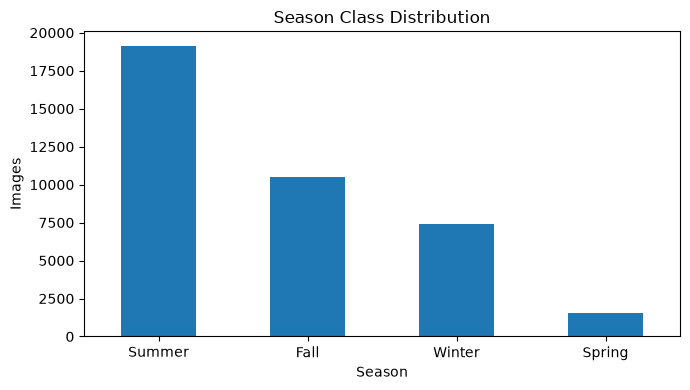

In [31]:
# ============================================
# CELL 5 - Season class distribution
# ============================================

season_counts = season_df["season"].value_counts()

season_percent = (
    season_df["season"]
    .value_counts(normalize=True)
    .mul(100)
)

season_summary = pd.DataFrame({
    "Count": season_counts,
    "Percentage": season_percent.round(2)
})

display(season_summary)

ax = season_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Season Class Distribution")
ax.set_xlabel("Season")
ax.set_ylabel("Images")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# ============================================
# CELL 6 - Encode target and grouping variable
# ============================================

CLASS_NAMES = [
    "Fall",
    "Spring",
    "Summer",
    "Winter"
]

class_to_index = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

season_df["label"] = (
    season_df["season"]
    .map(class_to_index)
    .astype("int64")
)

season_df["split_group"] = (
    season_df["productDisplayName"]
    .fillna(
        "__ID_" + season_df["id"].astype(str)
    )
)

print("Class mapping:")
print(class_to_index)

print(
    "\nUnique split groups:",
    season_df["split_group"].nunique()
)

Class mapping:
{'Fall': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

Unique split groups: 27533


## 3. Splitting without leakage

The catalogue contains multiple photographs of the same product. A random split
would put some of those photographs in training and others in test, so the model
could score well by recognising an item it had already memorised rather than by
learning what makes something a Summer garment.

The split is therefore **grouped by product** and stratified on the season label
at the same time, using `StratifiedGroupKFold`. Grouping alone would break the
class balance across folds; stratifying alone would leak. The check that follows
is not decoration - it asserts zero group overlap between all three splits, and
the split is only trustworthy because that assertion passes.

In [33]:
# ============================================
# CELL 7 - Leakage-safe grouped split
# ============================================

outer_splitter = StratifiedGroupKFold(
    n_splits=7,
    shuffle=True,
    random_state=SEED
)

trainval_idx, test_idx = next(
    outer_splitter.split(
        season_df,
        y=season_df["label"],
        groups=season_df["split_group"]
    )
)

trainval_df = (
    season_df.iloc[trainval_idx]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    season_df.iloc[test_idx]
    .copy()
    .reset_index(drop=True)
)

inner_splitter = StratifiedGroupKFold(
    n_splits=6,
    shuffle=True,
    random_state=SEED
)

train_idx, val_idx = next(
    inner_splitter.split(
        trainval_df,
        y=trainval_df["label"],
        groups=trainval_df["split_group"]
    )
)

train_df = (
    trainval_df.iloc[train_idx]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    trainval_df.iloc[val_idx]
    .copy()
    .reset_index(drop=True)
)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print(
    "\nPercentage:",
    {
        "train": round(
            len(train_df) / len(season_df) * 100, 2
        ),
        "validation": round(
            len(val_df) / len(season_df) * 100, 2
        ),
        "test": round(
            len(test_df) / len(season_df) * 100, 2
        )
    }
)

Train      : 27565
Validation : 5513
Test       : 5514

Percentage: {'train': 71.43, 'validation': 14.29, 'test': 14.29}


In [34]:
# ============================================
# CELL 8 - Verify group leakage
# ============================================

train_groups = set(train_df["split_group"])
val_groups = set(val_df["split_group"])
test_groups = set(test_df["split_group"])

train_val_overlap = train_groups & val_groups
train_test_overlap = train_groups & test_groups
val_test_overlap = val_groups & test_groups

print(
    "Train / Validation group overlap:",
    len(train_val_overlap)
)

print(
    "Train / Test group overlap:",
    len(train_test_overlap)
)

print(
    "Validation / Test group overlap:",
    len(val_test_overlap)
)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\nLeakage check PASSED.")

Train / Validation group overlap: 0
Train / Test group overlap: 0
Validation / Test group overlap: 0

Leakage check PASSED.


In [35]:
# ============================================
# CELL 9 - Verify class distributions
# ============================================

def distribution(df):
    return (
        df["season"]
        .value_counts(normalize=True)
        .reindex(CLASS_NAMES)
        .mul(100)
        .round(2)
    )

split_distribution = pd.DataFrame({
    "Train %": distribution(train_df),
    "Validation %": distribution(val_df),
    "Test %": distribution(test_df)
})

display(split_distribution)

,Train %,Validation %,Test %
season,,,
Fall,27.24,27.24,27.24
Spring,4.06,4.06,4.04
Summer,49.58,49.57,49.58
Winter,19.12,19.12,19.13


## 4. Correcting for the imbalance

Balanced class weights are computed from the training split and passed to the
loss, so that a Spring example contributes roughly twelve times the gradient of a
Summer one.

The alternative - resampling - was not used. At this imbalance it would either
discard most of the Summer data or repeat the small Spring set many times per
epoch, and with only around fifteen hundred Spring images the second option
overfits them quickly. Weighting the loss keeps every image and every epoch
intact.

In [36]:
# ============================================
# CELL 10 - Compute class weights
# ============================================

classes = np.arange(len(CLASS_NAMES))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

CLASS_WEIGHTS = {
    int(i): float(w)
    for i, w in zip(classes, weights)
}

print("Class weights:")

for class_index, weight in CLASS_WEIGHTS.items():
    print(
        f"{index_to_class[class_index]:7s}: "
        f"{weight:.4f}"
    )

Class weights:
Fall   : 0.9179
Spring : 6.1584
Summer : 0.5042
Winter : 1.3076


## 5. Preprocessing

Images are resized to 80x60 and converted to tensors. There is deliberately **no
channel normalisation**: the catalogue is overwhelmingly light-background product
photography with little variation to normalise away, and leaving the values in
[0, 1] keeps the serving path in `app/backend/services/task2_service.py` trivially
identical to the training transform. That equivalence matters more than a marginal
convergence gain - a mismatch between the two is silent and shifts every
prediction.

In [37]:
# ============================================
# CELL 11 - PyTorch Dataset and preprocessing
# ============================================

IMAGE_SIZE = (80, 60)  # height, width
BATCH_SIZE = 64

eval_transform = transforms.Compose([
    transforms.Resize(
        IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor()
])

class FashionSeasonDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        has_labels=True
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        if self.has_labels:
            label = int(row["label"])
            return image, label

        return image


# Quick preprocessing test
sample_dataset = FashionSeasonDataset(
    train_df.head(5),
    transform=eval_transform
)

sample_image, sample_label = sample_dataset[0]

print("Tensor shape :", sample_image.shape)
print("Tensor dtype :", sample_image.dtype)
print(
    "Pixel range  :",
    float(sample_image.min()),
    "to",
    float(sample_image.max())
)
print("Label        :", sample_label)

Tensor shape : torch.Size([3, 80, 60])
Tensor dtype : torch.float32
Pixel range  : 0.0117647061124444 to 1.0
Label        : 2


## 6. The baseline that has to be beaten

Always predicting the majority class is the honest floor. Its accuracy looks
respectable precisely because the data is imbalanced, and its macro-F1 does not -
which is the clearest possible demonstration of why accuracy is the wrong headline
for this task.

Any model that cannot beat this on macro-F1 has learned nothing about season.

In [38]:
# ============================================
# CELL 12 - Majority-class baseline
# ============================================

majority_class = (
    train_df["season"]
    .value_counts()
    .idxmax()
)

baseline_predictions = np.full(
    len(test_df),
    class_to_index[majority_class]
)

y_test = test_df["label"].values

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_macro_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="macro",
    zero_division=0
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_predictions
)

print("Majority class:", majority_class)

print(
    f"Accuracy          : "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Macro-F1          : "
    f"{baseline_macro_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{baseline_balanced_accuracy:.4f}"
)

Majority class: Summer
Accuracy          : 0.4958
Macro-F1          : 0.1657
Balanced Accuracy : 0.2500


## 7. Augmentation, architecture and training

Augmentation is geometric and photometric but conservative - flips, small affine
jitter and colour jitter. Nothing that would change the answer: a strong hue shift
would turn a Summer palette into an Autumn one and corrupt the label.

The network is a compact VGG-style CNN - three blocks of paired 3x3 convolutions
with batch normalisation, then global average pooling and a small classifier.
Global pooling rather than a flattened head keeps the parameter count low, which
suits a four-class problem with fifteen hundred examples in its rarest class.
Training uses the weighted cross-entropy from section 4, Adam, and early stopping
on validation macro-F1.

In [39]:
# ============================================
# CELL 13 - Data augmentation and DataLoaders
# ============================================

train_transform = transforms.Compose([

    transforms.Resize(
        IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomAffine(
        degrees=5,
        translate=(0.05, 0.05),
        scale=(0.92, 1.08),
        interpolation=InterpolationMode.BILINEAR
    ),

    transforms.ColorJitter(
        contrast=0.10
    ),

    transforms.ToTensor()
])

train_dataset = FashionSeasonDataset(
    train_df,
    transform=train_transform
)

val_dataset = FashionSeasonDataset(
    val_df,
    transform=eval_transform
)

test_dataset = FashionSeasonDataset(
    test_df,
    transform=eval_transform
)

# num_workers=0 is safest inside Jupyter on macOS
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Batch images :", images.shape)
print("Batch labels :", labels.shape)

print(
    "Train batches      :",
    len(train_loader)
)

print(
    "Validation batches :",
    len(val_loader)
)

print(
    "Test batches       :",
    len(test_loader)
)

Batch images : torch.Size([64, 3, 80, 60])
Batch labels : torch.Size([64])
Train batches      : 431
Validation batches : 87
Test batches       : 87


In [40]:
# ============================================
# CELL 14 - Custom CNN
# ============================================

class SeasonCNN(nn.Module):

    def __init__(self, num_classes=4):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(
                32, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                64, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(
                128, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


season_model = SeasonCNN(
    num_classes=len(CLASS_NAMES)
).to(DEVICE)

print(season_model)

total_params = sum(
    p.numel()
    for p in season_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in season_model.parameters()
    if p.requires_grad
)

print("\nTotal parameters     :", total_params)
print("Trainable parameters :", trainable_params)
print("Device               :", DEVICE)

SeasonCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, ke

In [41]:
# ============================================
# CELL 15 - Training configuration
# ============================================

class_weight_tensor = torch.tensor(
    [
        CLASS_WEIGHTS[i]
        for i in range(len(CLASS_NAMES))
    ],
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)

optimizer = torch.optim.Adam(
    season_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

BEST_MODEL_PATH = (
    TASK2_ARTIFACT_DIR /
    "task2_season_best_pytorch.pth"
)

print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Max epochs    :", MAX_EPOCHS)
print("Device        :", DEVICE)
print("Model path    :", BEST_MODEL_PATH)

Loss function : CrossEntropyLoss()
Optimizer     : Adam
Max epochs    : 30
Device        : mps
Model path    : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2/task2_season_best_pytorch.pth


In [42]:
# ============================================
# CELL 16 - Train CNN
# ============================================

history = {
    "accuracy": [],
    "loss": [],
    "val_accuracy": [],
    "val_loss": [],
    "learning_rate": []
}

best_val_loss = float("inf")
epochs_without_improvement = 0

training_start = time.time()

for epoch in range(MAX_EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    season_model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = season_model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss_sum += (
            loss.item() * images.size(0)
        )

        predictions_batch = (
            outputs.argmax(dim=1)
        )

        train_correct += (
            predictions_batch == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss = (
        train_loss_sum /
        train_total
    )

    train_accuracy = (
        train_correct /
        train_total
    )

    # -------------------------
    # Validation
    # -------------------------

    season_model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = season_model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss_sum += (
                loss.item() *
                images.size(0)
            )

            predictions_batch = (
                outputs.argmax(dim=1)
            )

            val_correct += (
                predictions_batch == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = (
        val_loss_sum /
        val_total
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    # Learning-rate scheduler
    scheduler.step(val_loss)

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    history["accuracy"].append(
        train_accuracy
    )

    history["loss"].append(
        train_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["learning_rate"].append(
        current_lr
    )

    improved = (
        val_loss <
        best_val_loss - 1e-4
    )

    if improved:

        best_val_loss = val_loss

        epochs_without_improvement = 0

        torch.save(
            season_model.state_dict(),
            BEST_MODEL_PATH
        )

        status = "BEST MODEL SAVED"

    else:

        epochs_without_improvement += 1
        status = "no improvement"

    print(
        f"Epoch {epoch + 1:02d}/{MAX_EPOCHS} | "
        f"loss={train_loss:.4f} | "
        f"acc={train_accuracy:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_accuracy:.4f} | "
        f"lr={current_lr:.6f} | "
        f"{status}"
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


training_seconds = (
    time.time() - training_start
)

print(
    "\nTraining time:",
    round(training_seconds / 60, 2),
    "minutes"
)

# Restore best model
season_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

season_model.eval()

print(
    "Best validation loss:",
    round(best_val_loss, 4)
)

print(
    "Best model restored from:",
    BEST_MODEL_PATH
)

Epoch 01/30 | loss=1.1767 | acc=0.3723 | val_loss=3.4184 | val_acc=0.3116 | lr=0.001000 | BEST MODEL SAVED
Epoch 02/30 | loss=0.9953 | acc=0.4870 | val_loss=1.0398 | val_acc=0.4740 | lr=0.001000 | BEST MODEL SAVED
Epoch 03/30 | loss=0.9330 | acc=0.5318 | val_loss=1.0391 | val_acc=0.5618 | lr=0.001000 | BEST MODEL SAVED
Epoch 04/30 | loss=0.9025 | acc=0.5471 | val_loss=0.9392 | val_acc=0.5162 | lr=0.001000 | BEST MODEL SAVED
Epoch 05/30 | loss=0.8775 | acc=0.5672 | val_loss=1.0460 | val_acc=0.4839 | lr=0.001000 | no improvement
Epoch 06/30 | loss=0.8716 | acc=0.5812 | val_loss=1.6179 | val_acc=0.3962 | lr=0.001000 | no improvement
Epoch 07/30 | loss=0.8516 | acc=0.5917 | val_loss=1.9050 | val_acc=0.3316 | lr=0.000500 | no improvement
Epoch 08/30 | loss=0.8131 | acc=0.6144 | val_loss=1.1311 | val_acc=0.5433 | lr=0.000500 | no improvement
Epoch 09/30 | loss=0.8046 | acc=0.6195 | val_loss=0.8745 | val_acc=0.6343 | lr=0.000500 | BEST MODEL SAVED
Epoch 10/30 | loss=0.8011 | acc=0.6190 | val_

,accuracy,loss,val_accuracy,val_loss,learning_rate
22,0.672012,0.706726,0.660439,0.798641,0.000125
23,0.670343,0.707486,0.627063,0.808204,0.000125
24,0.670560,0.701370,0.605478,0.842601,0.000063
25,0.675385,0.688539,0.673318,0.773504,0.000063
26,0.674225,0.691838,0.662978,0.777480,0.000063


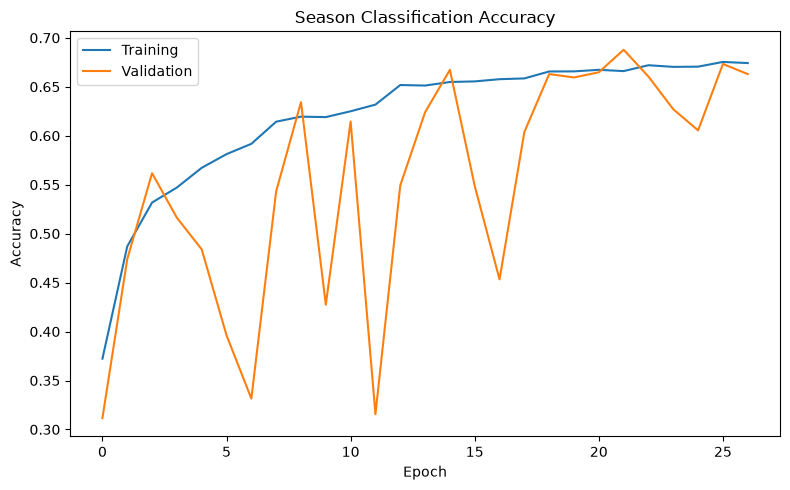

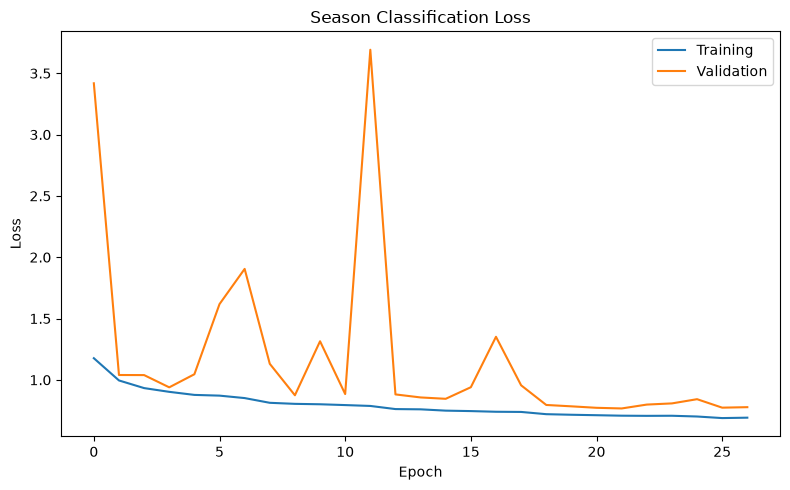

In [43]:
# ============================================
# CELL 17 - Training history and curves
# ============================================

history_df = pd.DataFrame(history)

display(history_df.tail())

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    label="Training"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation"
)

plt.title(
    "Season Classification Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Training"
)

plt.plot(
    history_df["val_loss"],
    label="Validation"
)

plt.title(
    "Season Classification Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.tight_layout()
plt.show()

## 8. Evaluation

Validation is used for model selection; the internal test split is scored once, at
the end. Confusion matrices are read alongside the headline numbers because with
four ordered-ish classes the *shape* of the errors matters - confusing Summer with
Spring is a different failure from confusing Summer with Winter.

In [45]:
# ============================================
# CELL 18 - Validation evaluation
# ============================================

def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions_batch = (
                probabilities.argmax(dim=1)
            )

            all_true.extend(
                labels.numpy()
            )

            all_pred.extend(
                predictions_batch
                .cpu()
                .numpy()
            )

            all_prob.extend(
                probabilities
                .cpu()
                .numpy()
            )

    return (
        np.array(all_true),
        np.array(all_pred),
        np.array(all_prob)
    )


val_true, val_pred, val_probs = evaluate_model(
    season_model,
    val_loader,
    DEVICE
)

val_accuracy = accuracy_score(
    val_true,
    val_pred
)

val_macro_f1 = f1_score(
    val_true,
    val_pred,
    average="macro"
)

val_weighted_f1 = f1_score(
    val_true,
    val_pred,
    average="weighted"
)


val_balanced_accuracy = balanced_accuracy_score(
    val_true,
    val_pred
)

print("=" * 50)
print("VALIDATION RESULTS")
print("=" * 50)

print(
    f"Accuracy          : "
    f"{val_accuracy:.4f}"
)

print(
    f"Macro-F1          : "
    f"{val_macro_f1:.4f}"
)

print(
    f"Weighted-F1       : "
    f"{val_weighted_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{val_balanced_accuracy:.4f}"
)

print("\nClassification report:\n")

print(
    classification_report(
        val_true,
        val_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

VALIDATION RESULTS
Accuracy          : 0.6878
Macro-F1          : 0.6541
Weighted-F1       : 0.6902
Balanced Accuracy : 0.7041

Classification report:

              precision    recall  f1-score   support

        Fall     0.6869    0.6178    0.6505      1502
      Spring     0.4521    0.7366    0.5603       224
      Summer     0.7688    0.6897    0.7271      2733
      Winter     0.6052    0.7723    0.6786      1054

    accuracy                         0.6878      5513
   macro avg     0.6282    0.7041    0.6541      5513
weighted avg     0.7023    0.6878    0.6902      5513



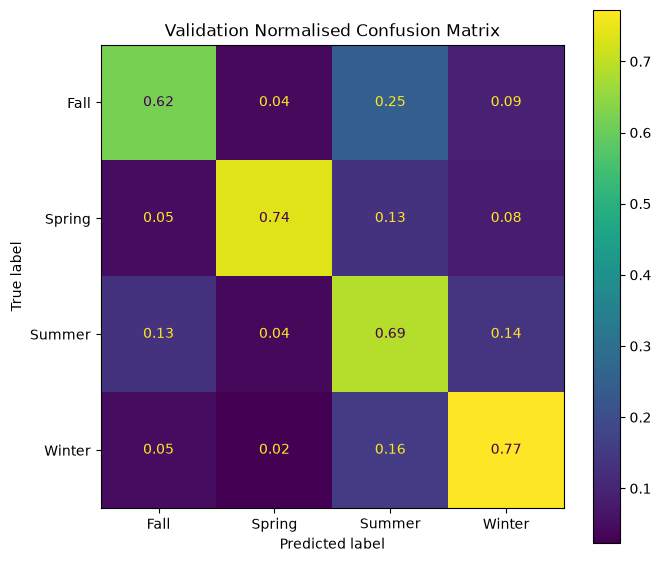

In [46]:
# ============================================
# CELL 19 - Validation confusion matrix
# ============================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    val_true,
    val_pred,
    display_labels=CLASS_NAMES,
    normalize="true",
    values_format=".2f",
    ax=ax
)

ax.set_title(
    "Validation Normalised Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [47]:
# ============================================
# CELL 20 - Final internal test evaluation
# ============================================

test_true, test_pred, test_probs = evaluate_model(
    season_model,
    test_loader,
    DEVICE
)

test_accuracy = accuracy_score(
    test_true,
    test_pred
)

test_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro"
)

test_weighted_f1 = f1_score(
    test_true,
    test_pred,
    average="weighted"
)

test_balanced_accuracy = balanced_accuracy_score(
    test_true,
    test_pred
)

print("=" * 50)
print("FINAL SEASON TEST RESULTS")
print("=" * 50)

print(
    f"Accuracy          : "
    f"{test_accuracy:.4f}"
)

print(
    f"Macro-F1          : "
    f"{test_macro_f1:.4f}"
)

print(
    f"Weighted-F1       : "
    f"{test_weighted_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{test_balanced_accuracy:.4f}"
)

print("\nClassification report:\n")

print(
    classification_report(
        test_true,
        test_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

FINAL SEASON TEST RESULTS
Accuracy          : 0.6754
Macro-F1          : 0.6432
Weighted-F1       : 0.6782
Balanced Accuracy : 0.6991

Classification report:

              precision    recall  f1-score   support

        Fall     0.6708    0.6065    0.6371      1502
      Spring     0.4432    0.7354    0.5531       223
      Summer     0.7753    0.6639    0.7153      2734
      Winter     0.5772    0.7905    0.6672      1055

    accuracy                         0.6754      5514
   macro avg     0.6166    0.6991    0.6432      5514
weighted avg     0.6955    0.6754    0.6782      5514



In [48]:
# ============================================
# CELL 21 - Baseline vs final PyTorch CNN
# ============================================

comparison = pd.DataFrame({

    "Model": [
        "Majority Baseline",
        "PyTorch CNN"
    ],

    "Accuracy": [
        baseline_accuracy,
        test_accuracy
    ],

    "Macro-F1": [
        baseline_macro_f1,
        test_macro_f1
    ],

    "Balanced Accuracy": [
        baseline_balanced_accuracy,
        test_balanced_accuracy
    ]
})

display(
    comparison.round(4)
)

,Model,Accuracy,Macro-F1,Balanced Accuracy
0,Majority Baseline,0.4958,0.1657,0.2500
1,PyTorch CNN,0.6754,0.6432,0.6991


## 9. Where the model fails

The error analysis below looks at high-confidence mistakes specifically. A
low-confidence error is the model correctly signalling that a photograph does not
determine its season; a high-confidence error is the model being wrong for a
reason worth understanding.

Expect the residual to concentrate on garments that genuinely carry no seasonal
signal - plain single-colour basics - and on Spring, which the model sees least
often and which sits visually between Summer and Fall.

In [49]:
# ============================================
# CELL 22 - Error analysis
# ============================================

error_df = test_df.copy()

error_df["true_season"] = [
    index_to_class[int(i)]
    for i in test_true
]

error_df["predicted_season"] = [
    index_to_class[int(i)]
    for i in test_pred
]

error_df["confidence"] = (
    test_probs.max(axis=1)
)

misclassified = (
    error_df[
        error_df["true_season"]
        != error_df["predicted_season"]
    ]
    .copy()
    .sort_values(
        "confidence",
        ascending=False
    )
)

print(
    "Total test observations :",
    len(error_df)
)

print(
    "Misclassified           :",
    len(misclassified)
)

print(
    "Error rate              :",
    round(
        len(misclassified)
        / len(error_df),
        4
    )
)

error_columns = [
    column
    for column in [
        "id",
        "articleType",
        "productDisplayName",
        "true_season",
        "predicted_season",
        "confidence"
    ]
    if column in misclassified.columns
]

display(
    misclassified[
        error_columns
    ].head(20)
)

Total test observations : 5514
Misclassified           : 1790
Error rate              : 0.3246


,id,articleType,productDisplayName,true_season,predicted_season,confidence
5464,51566,Watches,Fastrack Women White Dial Watch NB6027sm01,Summer,Winter,0.999275
3456,31858,Watches,Titan Edge Men Black Dial Watch NH679SL02A,Summer,Winter,0.998823
874,8915,Shoe Accessories,Timberland Unisex Black Boot Sauce Cream,Fall,Spring,0.998363
5466,51579,Watches,Fastrack Men Black Dial watch NB3039sm02,Summer,Winter,0.998124
4535,43188,Watches,Fastrack Men Steel Dial Watch N9336SL02,Summer,Winter,0.997012
4530,43153,Watches,Fastrack Men Brown Dial Watch NE1478SM02,Summer,Winter,0.995574
3261,29872,Sunglasses,Mayhem Men Rectangular Sunglasses 1022-201,Summer,Winter,0.994459
4776,46123,Necklace and Chains,Adrika Black Necklace,Summer,Winter,0.992794
3260,29871,Sunglasses,Mayhem Men Rectangular Sunglasses 1022-203,Summer,Winter,0.991913
3280,30068,Watches,Ed Hardy Men Silver Dial Watch,Summer,Winter,0.991075


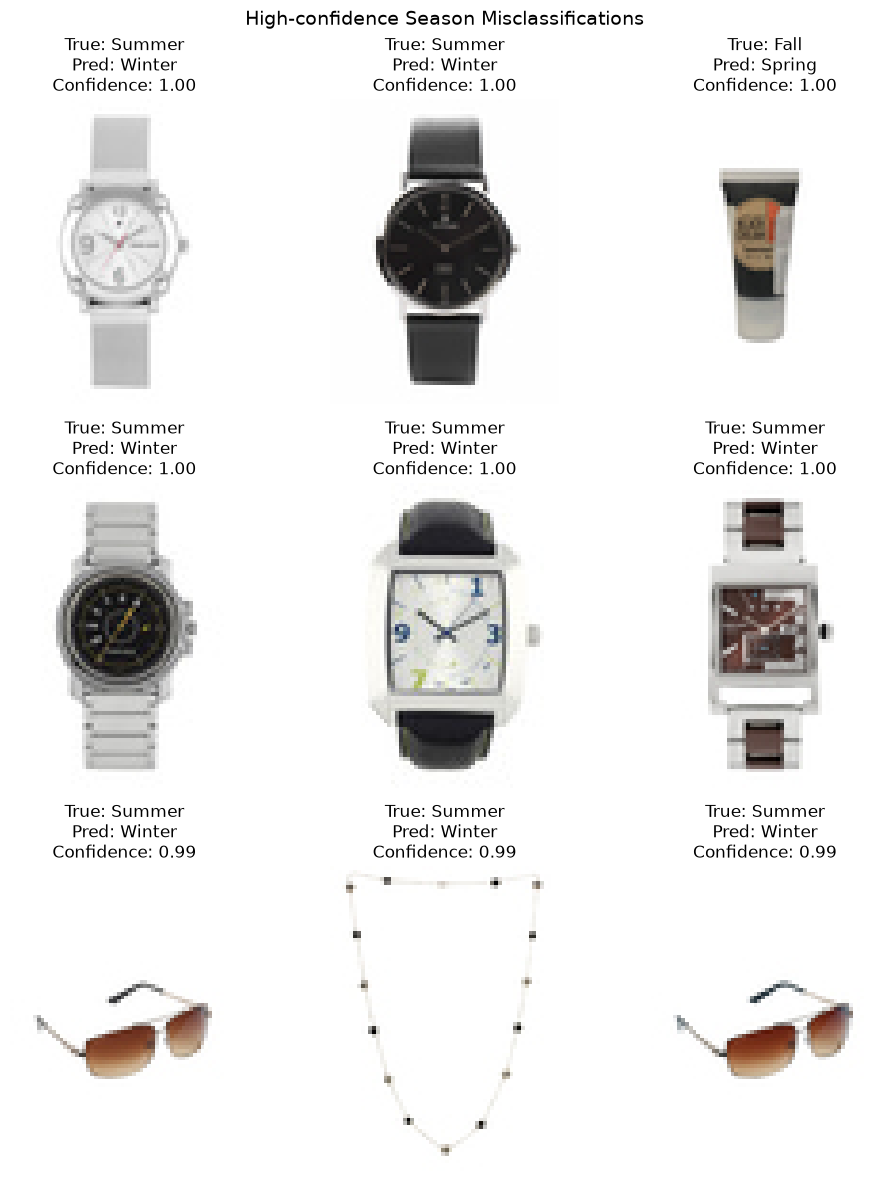

In [50]:
# ============================================
# CELL 23 - Visualise high-confidence mistakes
# ============================================

examples = (
    misclassified
    .head(9)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(10, 12)
)

axes = axes.flatten()

for index, ax in enumerate(axes):

    if index >= len(examples):
        ax.axis("off")
        continue

    row = examples.iloc[index]

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    ax.imshow(
        image,
        interpolation="nearest"
    )

    ax.set_title(
        f"True: {row['true_season']}\n"
        f"Pred: {row['predicted_season']}\n"
        f"Confidence: {row['confidence']:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "High-confidence Season Misclassifications",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 10. Predictions and artefacts

Predictions are written for the held-out competition images, and the checkpoint,
class mapping and metrics are saved to `artifacts/task2/` so the API can serve
this model without re-training.

Note the class mapping is saved as a separate file from the weights. The
checkpoint itself is a bare `state_dict` with no metadata, so the mapping, the
image size and the preprocessing are all conventions held outside it -
`tests/test_season_gender_usage_models.py` exists to assert they still agree.

In [51]:
# ============================================
# CELL 24 - Build unseen test DataLoader
# ============================================

unseen_dataset = FashionSeasonDataset(
    prediction,
    transform=eval_transform,
    has_labels=False
)

unseen_loader = DataLoader(
    unseen_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "Unseen images:",
    len(unseen_dataset)
)

print(
    "Unseen batches:",
    len(unseen_loader)
)

assert len(unseen_dataset) == 5829

Unseen images: 5829
Unseen batches: 92


In [52]:
# ============================================
# CELL 25 - Predict unseen images
# ============================================

season_model.eval()

unseen_probabilities = []

with torch.no_grad():

    for images in unseen_loader:

        images = images.to(DEVICE)

        outputs = season_model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        unseen_probabilities.append(
            probabilities
            .cpu()
            .numpy()
        )

unseen_probabilities = np.concatenate(
    unseen_probabilities,
    axis=0
)

unseen_pred_indices = (
    unseen_probabilities.argmax(axis=1)
)

unseen_pred_labels = [
    index_to_class[int(index)]
    for index in unseen_pred_indices
]

print(
    "Predictions generated:",
    len(unseen_pred_labels)
)

print("\nPrediction distribution:")

print(
    pd.Series(
        unseen_pred_labels
    ).value_counts()
)

assert len(unseen_pred_labels) == 5829

Predictions generated: 5829

Prediction distribution:
Summer    2664
Winter    1682
Spring    1269
Fall       214
Name: count, dtype: int64


In [53]:
# ============================================
# CELL 26 - Export prediction CSV
# ============================================

required_columns = [
    "id",
    "gender",
    "articleType",
    "season",
    "usage"
]

submission = (
    prediction[
        required_columns
    ]
    .copy()
)

submission["season"] = (
    unseen_pred_labels
)

OUTPUT_PREDICTION_PATH = (
    TASK2_ARTIFACT_DIR /
    "task2_season_predictions.csv"
)

submission.to_csv(
    OUTPUT_PREDICTION_PATH,
    index=False
)

print(
    "Saved prediction file:",
    OUTPUT_PREDICTION_PATH
)

print(
    "Shape:",
    submission.shape
)

print(
    "Missing Season predictions:",
    submission["season"].isna().sum()
)

display(
    submission.head()
)

assert submission.shape == (5829, 5)

assert (
    submission["season"]
    .isna()
    .sum()
    == 0
)

Saved prediction file: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2/task2_season_predictions.csv
Shape: (5829, 5)
Missing Season predictions: 0


,id,gender,articleType,season,usage
0,52003,NaN,NaN,Fall,NaN
1,52007,NaN,NaN,Summer,NaN
2,52017,NaN,NaN,Summer,NaN
3,52021,NaN,NaN,Summer,NaN
4,52023,NaN,NaN,Summer,NaN


In [54]:
# ============================================
# CELL 27 - Save artifacts and metrics
# ============================================

CLASS_MAPPING_PATH = (
    TASK2_ARTIFACT_DIR /
    "task2_season_class_mapping.json"
)

METRICS_PATH = (
    TASK2_ARTIFACT_DIR /
    "task2_season_metrics.json"
)

with open(
    CLASS_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        class_to_index,
        file,
        indent=4
    )


metrics = {

    "framework": "PyTorch",

    "device": str(DEVICE),

    "epochs_completed":
        len(history_df),

    "baseline": {
        "accuracy":
            float(baseline_accuracy),

        "macro_f1":
            float(baseline_macro_f1),

        "balanced_accuracy":
            float(
                baseline_balanced_accuracy
            )
    },

    "validation": {
        "accuracy":
            float(val_accuracy),

        "macro_f1":
            float(val_macro_f1),

        "weighted_f1":
            float(val_weighted_f1),

        "balanced_accuracy":
            float(val_balanced_accuracy)
    },

    "test": {
        "accuracy":
            float(test_accuracy),

        "macro_f1":
            float(test_macro_f1),

        "weighted_f1":
            float(test_weighted_f1),

        "balanced_accuracy":
            float(test_balanced_accuracy)
    },

    "training_minutes":
        float(training_seconds / 60),

    "best_model":
        str(BEST_MODEL_PATH)
}


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )


print("=" * 50)
print("TASK 2 PYTORCH COMPLETE")
print("=" * 50)

print(
    "Model   :",
    BEST_MODEL_PATH
)

print(
    "Mapping :",
    CLASS_MAPPING_PATH
)

print(
    "Metrics :",
    METRICS_PATH
)

print(
    "CSV     :",
    OUTPUT_PREDICTION_PATH
)

print("\nFinal Test Results")

print(
    f"Accuracy          : "
    f"{test_accuracy:.4f}"
)

print(
    f"Macro-F1          : "
    f"{test_macro_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{test_balanced_accuracy:.4f}"
)

TASK 2 PYTORCH COMPLETE
Model   : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2/task2_season_best_pytorch.pth
Mapping : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2/task2_season_class_mapping.json
Metrics : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2/task2_season_metrics.json
CSV     : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2/task2_season_predictions.csv

Final Test Results
Accuracy          : 0.6754
Macro-F1          : 0.6432
Balanced Accuracy : 0.6991


## What this task established, and what it did not

**Established.** Season is predictable from a 60x80 photograph well above chance:
macro-F1 rises from roughly 0.17 for the majority-class baseline to roughly 0.64,
and balanced accuracy from 0.25 to about 0.70. The grouped split means that gain
is not memorised product identity, and the weighted loss means it is not four
classes collapsed into one.

**Not established.** Only one architecture was trained here. The comparison in
this notebook is model-versus-baseline, not model-versus-model, so it shows that
the CNN works without showing that it is the best available choice - a gap worth
naming rather than glossing.

**The ceiling is the label, not the network.** Roughly a third of items remain
misclassified, concentrated on garments whose appearance genuinely does not
determine a season. That is a property of the target: season is assigned by a
merchandiser, and a plain black t-shirt looks the same whichever season it is
stocked for. A larger model does not recover information the photograph never
contained, which is why the sensible product treatment is to present season as a
suggestion rather than a label.